# Reservoir statistics analysis

This notebook documents Compulsory Assignment 1 for IND320. It reads the original `reservoirs.csv` file supplied with the course material. The source file is never modified.

**Data source:** `Curriculum/D2Dbook/data/reservoirs.csv`

## 1. Read the source data

The code first locates the IND320 project root. It then reads the CSV with Pandas into `df_raw`, which keeps the original Norwegian column names.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


def find_project_root(start_path: Path) -> Path:
    """Find the IND320 root by looking for the course data folder."""
    for candidate in (start_path, *start_path.parents):
        source_file = candidate / 'Curriculum' / 'D2Dbook' / 'data' / 'reservoirs.csv'
        if source_file.exists():
            return candidate

    raise FileNotFoundError('Could not find Curriculum/D2Dbook/data/reservoirs.csv.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'Curriculum' / 'D2Dbook' / 'data' / 'reservoirs.csv'

# Read the original CSV. This operation does not change the source file.
df_raw = pd.read_csv(DATA_PATH)

print(f'Read {len(df_raw):,} rows from: {DATA_PATH}')
df_raw.head()

Read 14,877 rows from: C:\Users\elias\Documents\IND320\Curriculum\D2Dbook\data\reservoirs.csv


,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## 2. Create an English analysis version

`df` is a copy used for analysis. Renaming its columns does not alter `df_raw` or the source CSV. The `date` column is converted to a date type, and the rows are sorted from oldest to newest before later plots are made.

In [2]:
COLUMN_NAMES = {
    'dato_Id': 'date',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'fill_level_ratio',
    'kapasitet_TWh': 'capacity_twh',
    'fylling_TWh': 'stored_energy_twh',
    'neste_Publiseringsdato': 'next_publication_date',
    'fyllingsgrad_forrige_uke': 'previous_week_fill_level_ratio',
    'endring_fyllingsgrad': 'weekly_fill_level_change',
}

# Make an analysis copy, rename the headers, and prepare the main time variable.
df = df_raw.rename(columns=COLUMN_NAMES).copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['date', 'area_type', 'area_number']).reset_index(drop=True)

df.head()

,date,area_type,area_number,iso_year,iso_week,fill_level_ratio,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level_ratio,weekly_fill_level_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
4,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160


## 3. Initial inspection

A relevant first view shows the first rows after sorting, the dimensions of the data set, the date range, and the data types.

In [3]:
print(f'Data set size: {df.shape[0]:,} rows and {df.shape[1]} columns')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')

display(df.head())
display(df.dtypes.rename('data_type').to_frame())

Data set size: 14,877 rows and 11 columns
Date range: 1995-01-08 to 2026-09-06


,date,area_type,area_number,iso_year,iso_week,fill_level_ratio,capacity_twh,stored_energy_twh,next_publication_date,previous_week_fill_level_ratio,weekly_fill_level_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
4,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160


,data_type
date,datetime64[us]
area_type,str
area_number,int64
iso_year,int64
iso_week,int64
fill_level_ratio,float64
capacity_twh,float64
stored_energy_twh,float64
next_publication_date,str
previous_week_fill_level_ratio,float64


## 4. Distribution of observations by area type

This bar chart counts the number of rows in each `area_type` category. It describes the structure of the data set, not the reservoir level or capacity of an area.

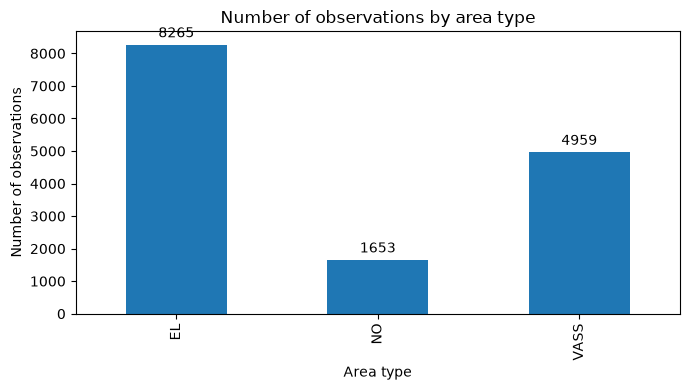

In [4]:
# Count how many observations belong to each area type.
area_type_counts = df['area_type'].value_counts().sort_index()

ax = area_type_counts.plot(
    kind='bar',
    color='#1f77b4',
    figsize=(7, 4),
)
ax.set_title('Number of observations by area type')
ax.set_xlabel('Area type')
ax.set_ylabel('Number of observations')
ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

## 5. Separate plots for measurement columns

The five measurement columns are plotted separately. Each line represents one area, so observations from different areas are never connected as if they belonged to the same time series. Fill levels are shown as percentages and weekly changes as percentage points. Capacity and stored energy are shown in TWh.

`area_type`, `area_number`, `iso_year`, and `iso_week` are identifiers or time information. They are used to identify and order the data, rather than being plotted as measurements.

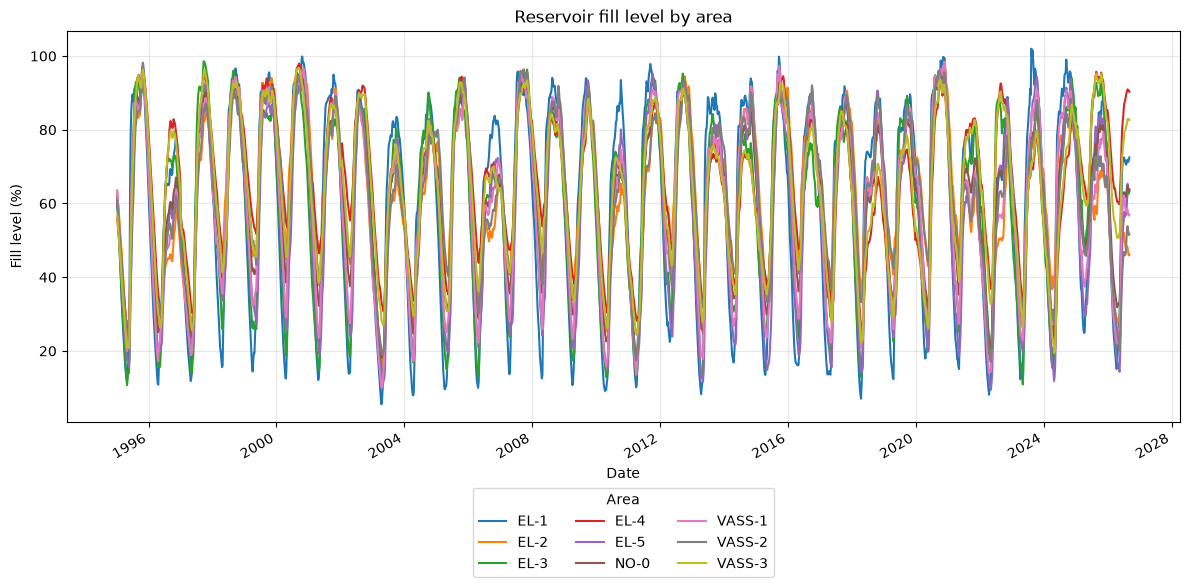

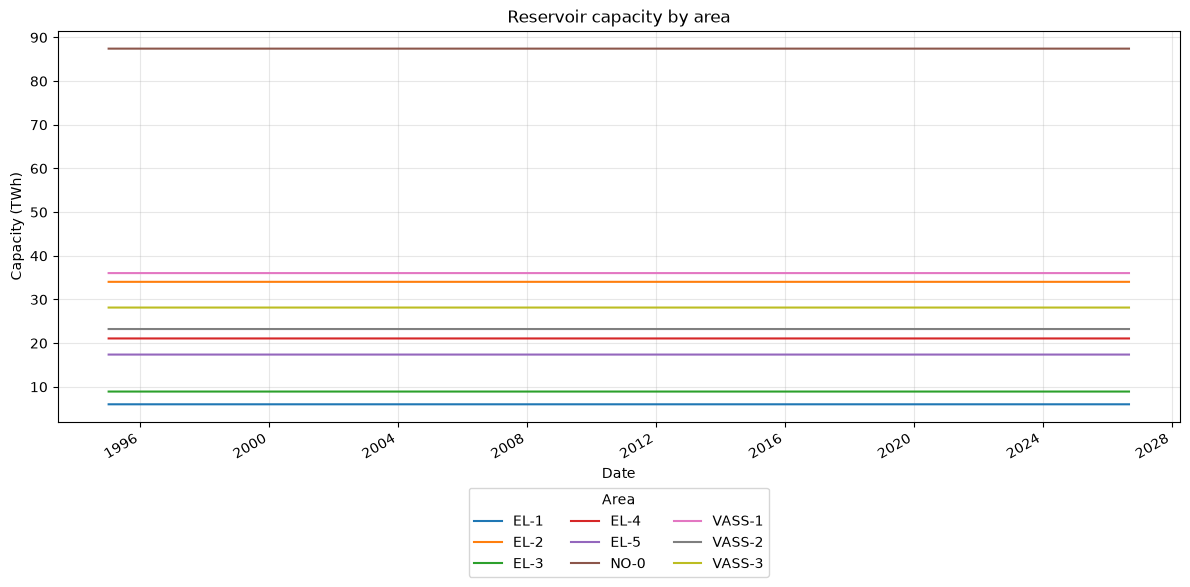

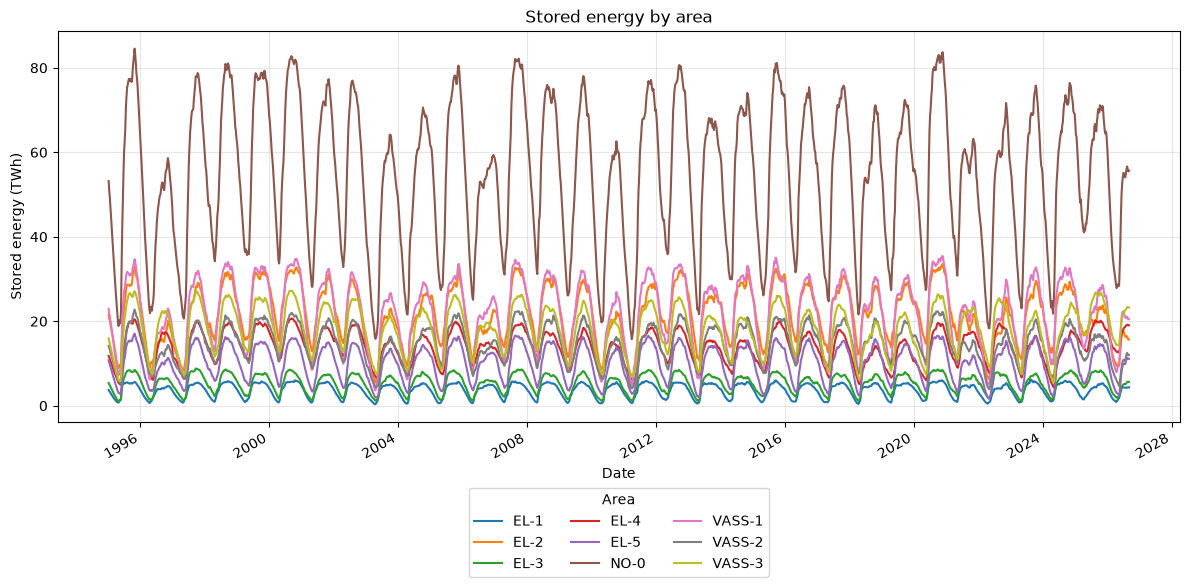

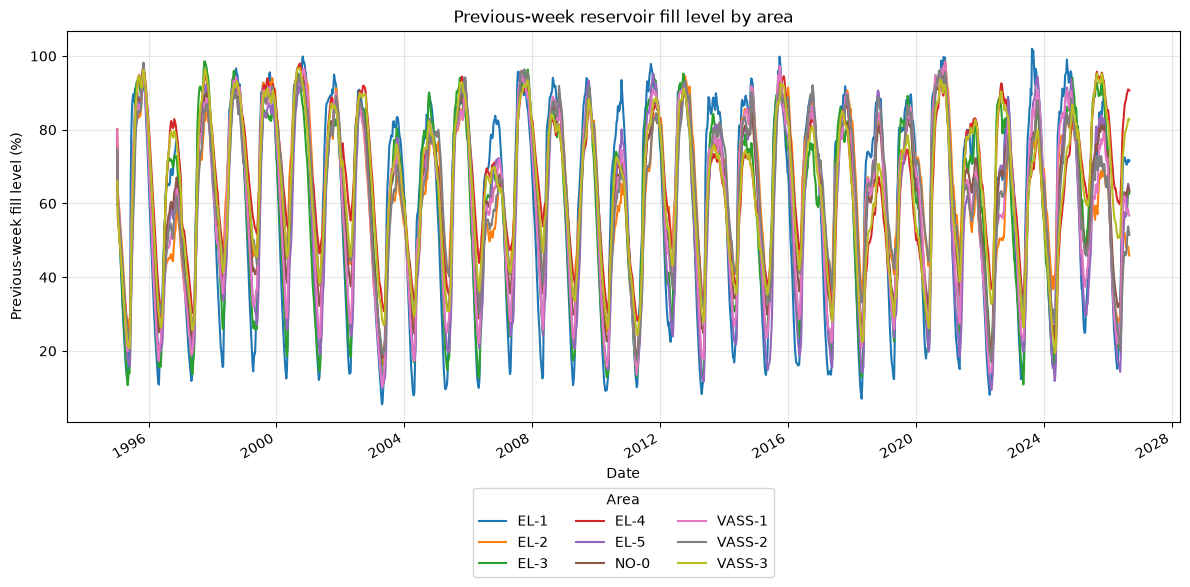

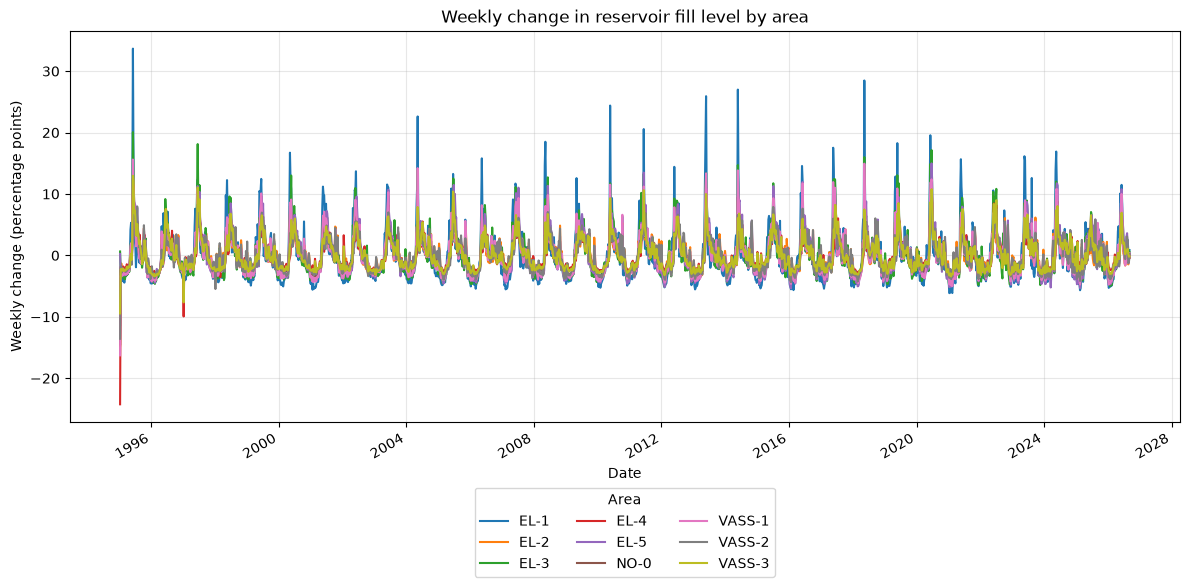

In [5]:
# Create a readable label for each unique area time series.
plot_data = df.assign(
    area_label=df['area_type'] + '-' + df['area_number'].astype(str)
)

# Store presentation details in one dictionary to avoid repeating plotting code.
PLOT_SETTINGS = {
    'fill_level_ratio': {
        'title': 'Reservoir fill level by area',
        'y_label': 'Fill level (%)',
        'multiplier': 100,
    },
    'capacity_twh': {
        'title': 'Reservoir capacity by area',
        'y_label': 'Capacity (TWh)',
        'multiplier': 1,
    },
    'stored_energy_twh': {
        'title': 'Stored energy by area',
        'y_label': 'Stored energy (TWh)',
        'multiplier': 1,
    },
    'previous_week_fill_level_ratio': {
        'title': 'Previous-week reservoir fill level by area',
        'y_label': 'Previous-week fill level (%)',
        'multiplier': 100,
    },
    'weekly_fill_level_change': {
        'title': 'Weekly change in reservoir fill level by area',
        'y_label': 'Weekly change (percentage points)',
        'multiplier': 100,
    },
}

# Draw one figure per measurement column, with one line per area.
for column, settings in PLOT_SETTINGS.items():
    fig, ax = plt.subplots(figsize=(12, 6))

    for area_label, area_data in plot_data.groupby('area_label', sort=True):
        ax.plot(
            area_data['date'],
            area_data[column] * settings['multiplier'],
            label=area_label,
            linewidth=1.5,
        )

    ax.set_title(settings['title'])
    ax.set_xlabel('Date')
    ax.set_ylabel(settings['y_label'])
    ax.grid(alpha=0.3)
    ax.legend(title='Area', ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.15))

    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

## 6. Combined multi-axis overview for Norway

The national measurement columns have different units and some are mathematically related. This single figure therefore keeps the original units instead of normalizing them. The top panel uses a percentage axis for fill levels and a TWh axis for stored energy and capacity. The lower panel shows weekly change in percentage points. Together, the two panels provide one readable overview of all five measurement columns.

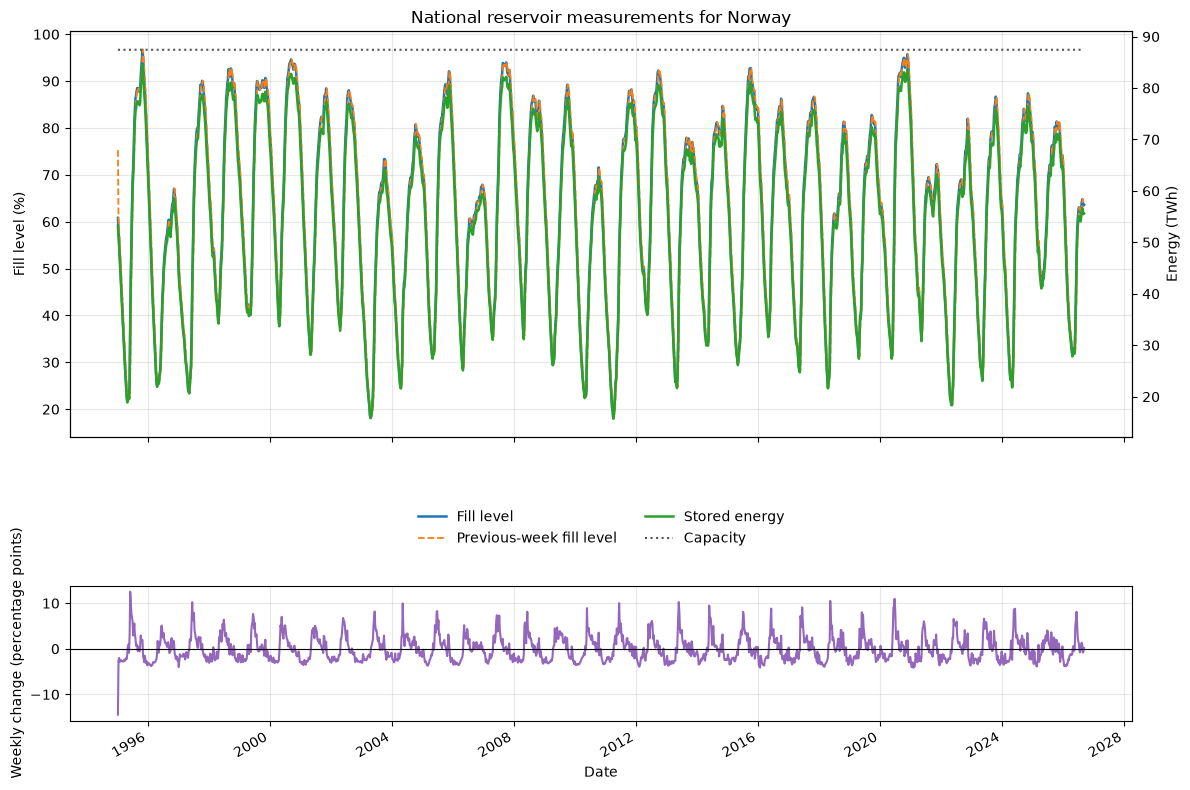

In [6]:
import sys

# Make the reusable project module available when Jupyter starts in notebooks/.
PROJECT_CODE_PATH = PROJECT_ROOT / 'Compulsory Assignments'
if str(PROJECT_CODE_PATH) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE_PATH))

from modules.plotting import plot_national_overview

# Select the single national time series so the combined figure remains readable.
national_data = df.loc[
    (df['area_type'] == 'NO') & (df['area_number'] == 0)
].copy()

# Use the reusable function so the full and short time-period charts share style.
plot_national_overview(
    national_data,
    'National reservoir measurements for Norway',
)


## 7. Detailed overview of the last five years

This version uses the same variables and units as the full-period overview, but only includes the five years leading up to the most recent observation. Fewer observations make recent changes easier to inspect.

Detailed period: 2021-09-12 to 2026-09-06
Observations in detailed period: 261


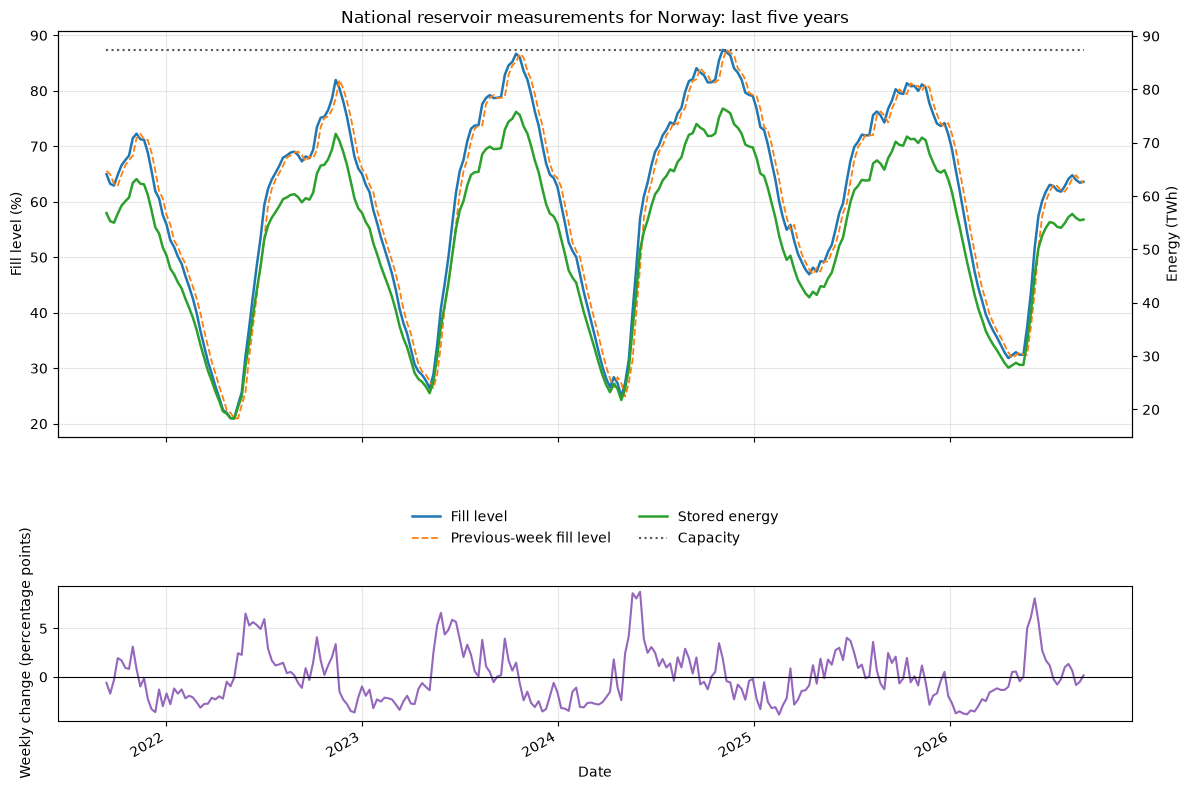

In [7]:
# Find the date five years before the latest available observation.
five_year_start = national_data['date'].max() - pd.DateOffset(years=5)
recent_data = national_data.loc[national_data['date'] >= five_year_start].copy()

print(
    f'Detailed period: {recent_data["date"].min().date()} '
    f'to {recent_data["date"].max().date()}'
)
print(f'Observations in detailed period: {len(recent_data)}')

# Reuse the exact same plot design with only the shorter data period changed.
plot_national_overview(
    recent_data,
    'National reservoir measurements for Norway: last five years',
)
